# Analysis of the social and economic impact on the well-being of peoples

### Phase 1: Ask
1. Background & Topic Exploration
The primary focus of this project is to explore global happiness levels to deeply understand the underlying factors and causes that contribute to a nation's overall well-being.

2. Business Task
To analyze the socio-economic impact on populations' well-being. Specifically, the task aims to evaluate how economic indicators (such as GDP per capita) compare against social indicators (such as social support, health, and freedom) in influencing national happiness scores, tracking these trends over a 5-year period (2015-2019).

3. Data Sources
The analysis utilizes the "World Happiness Report" datasets (2015-2019), made available by the Sustainable Development Solutions Network under a CC0 license.

4. Key Stakeholders & Audience

Primary Stakeholders: Global policymakers, government planners, and international NGOs (Non-Governmental Organizations) focused on human development.

Audience: Socioeconomic researchers and the general public interested in global well-being metrics.

5. Key Metrics Used for Analysis
The objective will be achieved by measuring and correlating the following key metrics:

Happiness Score (The primary dependent variable)

Economy (GDP per Capita)

Family / Social Support

Health (Life Expectancy)

Freedom to make life choices

### Phase 2: Prepare
1. Data Location and Organization
The data consists of five separate CSV files, each representing a year of the World Happiness Report from 2015 to 2019. The files have been stored locally in a secure, dedicated directory with structured subfolders separating the raw datasets from the soon-to-be processed files to ensure data integrity.

2. Data Credibility (ROCCC Evaluation)
The datasets meet the ROCCC framework standards:

**Reliable & Original:** The data is compiled from the Gallup World Poll and published by the Sustainable Development Solutions Network.

**Comprehensive:** It includes structured scores and distinct socioeconomic variables for over 150 countries.

**Current & Cited:** The 5-year timeline (2015-2019) provides a solid, consecutive historical baseline for trend analysis, and the report is heavily cited in global developmental research

3. Data Loading and Environment Setup

In preparation for the **Process** phase, we perform the following technical setup:

**Library Imports**: We utilize `pandas` and `numpy` for data manipulation and structure, while `seaborn` and `matplotlib` are imported to support exploratory visualization.
**Data Acquisition**: Five separate CSV files (2015-2019) are loaded into individual DataFrames. These files contain the raw happiness scores and socio-economic variables provided by the World Happiness Report.
**Data Inspection**: Initial previews of the data (using `.head()`) allow us to identify structural differences in column naming and data types across different years, which is essential for the subsequent cleaning and merging steps.

In [ ]:
# First we need to import libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import plotly.express as px

In [ ]:
# Load Datasets from CSV files into pandas DataFrames
data_2015 = pd.read_csv('2015.csv')
data_2016 = pd.read_csv('2016.csv')
data_2017 = pd.read_csv('2017.csv')
data_2018 = pd.read_csv('2018.csv')
data_2019 = pd.read_csv('2019.csv')

In [ ]:
# Preview the first 5 rows of the 2015 dataset to understand its structure
data_2015.head(5)

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [ ]:
# Preview the first 5 rows of the 2016 dataset
data_2016.head(5)

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596


In [ ]:
# Preview the first 5 rows of the 2017 dataset
data_2017.head(5)

,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715
3,Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716
4,Finland,5,7.469,7.527542,7.410458,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182


In [ ]:
# Preview the first 5 rows of the 2018 dataset
data_2018.head(5)

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.632,1.305,1.592,0.874,0.681,0.202,0.393
1,2,Norway,7.594,1.456,1.582,0.861,0.686,0.286,0.340
2,3,Denmark,7.555,1.351,1.590,0.868,0.683,0.284,0.408
3,4,Iceland,7.495,1.343,1.644,0.914,0.677,0.353,0.138
4,5,Switzerland,7.487,1.420,1.549,0.927,0.660,0.256,0.357


In [ ]:
# Preview the first 5 rows of the 2019 dataset
data_2019.head(5)

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


3. Data Integrity and Technical Assessment
A preliminary technical review of the CSV files revealed several structural inconsistencies that will require programmatic cleaning before performing any aggregations or relational analyses:

**Inconsistent Naming:** Column headers vary significantly across the years (e.g., Economy (GDP per Capita) in 2015 vs. GDP per capita in 2019).

**Structural Discrepancies:** Key categorical variables are missing in certain years. For instance, the Region column is present in 2015 and 2016 but absent in 2017, 2018, and 2019.

**Feature Variability:** Some datasets contain statistical noise columns (e.g., Standard Error or Whisker-high) that are outside the scope of the current business task and need to be filtered out.

### Phase 3: Process


### 1. Standardizing Column Names and Adding Year Information


Now that the column names are standardized and each DataFrame has a 'Year' column, the next step is to combine all these individual yearly DataFrames into a single, comprehensive DataFrame. This unified dataset will allow for easier longitudinal analysis and comparison across the 5-year period (2015-2019).

This will involve using `pd.concat()` to stack the DataFrames vertically, ignoring the original index.

In [ ]:
# Define column name mappings for consistency across different years
mapping_15_16 = {
    'Happiness Rank': 'Rank', 'Happiness Score': 'Score',
    'Economy (GDP per Capita)': 'GDP', 'Health (Life Expectancy)': 'Health',
    'Trust (Government Corruption)': 'Corruption', 'Family': 'Social_Support'
}

mapping_17 = {
    'Happiness.Rank': 'Rank', 'Happiness.Score': 'Score',
    'Economy..GDP.per.Capita.': 'GDP', 'Health..Life.Expectancy.': 'Health',
    'Trust..Government.Corruption.': 'Corruption', 'Family': 'Social_Support'
}

mapping_18_19 = {
    'Overall rank': 'Rank', 'Country or region': 'Country', 'Score': 'Score',
    'GDP per capita': 'GDP', 'Healthy life expectancy': 'Health',
    'Perceptions of corruption': 'Corruption', 'Social support': 'Social_Support',
    'Freedom to make life choices': 'Freedom'
}

# Rename columns in each DataFrame using the defined mappings
df_2015 = data_2015.rename(columns=mapping_15_16)
df_2016 = data_2016.rename(columns=mapping_15_16)
df_2017 = data_2017.rename(columns=mapping_17)
df_2018 = data_2018.rename(columns=mapping_18_19)
df_2019 = data_2019.rename(columns=mapping_18_19)

# Add a 'Year' column to each DataFrame to identify the original year of the data
df_2015['Year'] = 2015
df_2016['Year'] = 2016
df_2017['Year'] = 2017
df_2018['Year'] = 2018
df_2019['Year'] = 2019

To ensure consistency and facilitate merging, the column names across all five DataFrames (2015-2019) were standardized. This step involved creating specific mapping dictionaries for different years to address variations in column nomenclature. Additionally, a new 'Year' column was added to each DataFrame, indicating the original year of the data. This is crucial for temporal trend analysis in later stages.

Key actions performed:
- **Defined `mapping_15_16`, `mapping_17`, and `mapping_18_19`**: These dictionaries specify how original column names from each year should be renamed to a unified set of names (e.g., 'Happiness Score' to 'Score', 'Economy (GDP per Capita)' to 'GDP').
- **Applied renaming**: The `.rename()` method was used on each DataFrame with its respective mapping dictionary.
- **Added 'Year' column**: A 'Year' column was created and populated with the corresponding year for each DataFrame (2015, 2016, 2017, 2018, 2019).

### 2. Merging Datasets


In [ ]:
frames = [df_2015, df_2016, df_2017, df_2018, df_2019]
merged_df = pd.concat(frames, ignore_index=True)
print(merged_df.shape)
print(merged_df.head(3))

(782, 18)
       Country          Region  Rank  Score  Standard Error      GDP  \
0  Switzerland  Western Europe     1  7.587         0.03411  1.39651   
1      Iceland  Western Europe     2  7.561         0.04884  1.30232   
2      Denmark  Western Europe     3  7.527         0.03328  1.32548   

   Social_Support   Health  Freedom  Corruption  Generosity  \
0         1.34951  0.94143  0.66557     0.41978     0.29678   
1         1.40223  0.94784  0.62877     0.14145     0.43630   
2         1.36058  0.87464  0.64938     0.48357     0.34139   

   Dystopia Residual  Year  Lower Confidence Interval  \
0            2.51738  2015                        NaN   
1            2.70201  2015                        NaN   
2            2.49204  2015                        NaN   

   Upper Confidence Interval  Whisker.high  Whisker.low  Dystopia.Residual  
0                        NaN           NaN          NaN                NaN  
1                        NaN           NaN          NaN          

### Clean Data

In [ ]:
merged_df.isna().sum()

,0
Country,0
Region,467
Rank,0
Score,0
Standard Error,624
GDP,0
Social_Support,0
Health,0
Freedom,0
Corruption,1


In [ ]:
region_dict = df_2015.set_index('Country')['Region'].to_dict()
merged_df['Region'] = merged_df['Region'].fillna(merged_df['Country'].map(region_dict))
missing_regions = merged_df['Region'].isnull().sum()
print(missing_regions)


19


Is small missing data so we can delete it

In [ ]:
merged_df.dropna(subset=['Region'], inplace=True)
missing_regions = merged_df['Region'].isnull().sum()
print(missing_regions)


0


In [ ]:
merged_df.head()

,Country,Region,Rank,Score,Standard Error,GDP,Social_Support,Health,Freedom,Corruption,Generosity,Dystopia Residual,Year,Lower Confidence Interval,Upper Confidence Interval,Whisker.high,Whisker.low,Dystopia.Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,2015,NaN,NaN,NaN,NaN,NaN
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,2015,NaN,NaN,NaN,NaN,NaN
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204,2015,NaN,NaN,NaN,NaN,NaN
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531,2015,NaN,NaN,NaN,NaN,NaN
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176,2015,NaN,NaN,NaN,NaN,NaN


Keep only the columns that serve our specific purpose.

In [ ]:
df = merged_df[['Country', 'Region', 'Year', 'Score', 'GDP', 'Social_Support', 'Health', 'Freedom', 'Corruption']]
df.head()


,Country,Region,Year,Score,GDP,Social_Support,Health,Freedom,Corruption
0,Switzerland,Western Europe,2015,7.587,1.39651,1.34951,0.94143,0.66557,0.41978
1,Iceland,Western Europe,2015,7.561,1.30232,1.40223,0.94784,0.62877,0.14145
2,Denmark,Western Europe,2015,7.527,1.32548,1.36058,0.87464,0.64938,0.48357
3,Norway,Western Europe,2015,7.522,1.45900,1.33095,0.88521,0.66973,0.36503
4,Canada,North America,2015,7.427,1.32629,1.32261,0.90563,0.63297,0.32957


### Data Dictionary (Variables Description)
After cleaning and standardizing the datasets across the 5 years, the final filtered dataframe consists of the following features:

| Column Name | Data Type | Description |
| :--- | :--- | :--- |
| **Country** | String | The name of the sovereign state or territory. |
| **Region** | String | The broad geographical region the country belongs to. |
| **Year** | Integer | The year the data was recorded (2015 - 2019). |
| **Score** | Float | The primary Happiness Score (0 to 10), also known as the "Cantril Ladder" score, based on the Gallup World Poll. |
| **GDP** | Float | The extent to which GDP per capita (economic output) contributes to the calculation of the Happiness Score. |
| **Social_Support** | Float | National average of having social safety nets (someone to count on in times of trouble). |
| **Health** | Float | The extent to which Healthy Life Expectancy at birth contributes to the Happiness Score. |
| **Freedom** | Float | National average of citizens' satisfaction with their freedom to make life choices. |
| **Corruption** | Float | National average of perceptions of corruption in government and businesses (a higher score means less perceived corruption). |
| **Generosity** | Float | The numerical value estimating the national average of recent charitable donations. |

In [ ]:
df.shape

(763, 9)

In [ ]:
df.describe(include="all")

,Country,Region,Year,Score,GDP,Social_Support,Health,Freedom,Corruption
count,763,763,763.000000,763.000000,763.000000,763.000000,763.000000,763.000000,762.000000
unique,164,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Switzerland,Sub-Saharan Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,5,186,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2016.967235,5.387557,0.919569,1.078899,0.615256,0.410528,0.125339
std,NaN,NaN,1.418929,1.129230,0.404454,0.330117,0.246577,0.152308,0.106198
min,NaN,NaN,2015.000000,2.693000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,2016.000000,4.508500,0.612965,0.870456,0.446000,0.309205,0.054000
50%,NaN,NaN,2017.000000,5.324000,0.985000,1.125000,0.650785,0.431000,0.089990
75%,NaN,NaN,2018.000000,6.208500,1.239710,1.330475,0.808579,0.531000,0.155340


In [ ]:
# Calculate the mean of 'GDP' grouped by 'Region', excluding 0 values for mean calculation
regional_gdp_means = df[df['GDP'] != 0].groupby('Region')['GDP'].transform('mean')

# Replace 0 values in the 'GDP' column with the calculated regional means
# Only replace if the original value is 0 and a regional mean is available
df.loc[(df['GDP'] == 0) & (df['Region'].isin(regional_gdp_means.index)), 'GDP'] = regional_gdp_means

print("0 values in 'GDP' column replaced with regional means.")

0 values in 'GDP' column replaced with regional means.


This step focuses specifically on the 'GDP' column to address the presence of '0' values. While a '0' GDP might indicate an extremely low economic output, for analytical consistency and to avoid skewing statistical models, these values are imputed.


In [ ]:
# Calculate the total count of '0' values in the DataFrame
total_zeros = (df == 0).sum().sum()
print(f"Total count of '0' values in the DataFrame: {total_zeros}")

Total count of '0' values in the DataFrame: 24


"During the data integrity check, values ​​equal to (0) were discovered in some sub-measures. After systematic examination, it was found that they represent the lower limit of the report's normalized scale and are not missing values ​​or input errors, so they were retained to ensure the accuracy and integrity of the analysis.

In [ ]:
# Check the type of the DataFrame 'df'
print(f"Type of df: {type(df)}")

# Check the current data type of the 'Year' column
print(f"Current dtype of 'Year' column: {df['Year'].dtype}")

# Convert the 'Year' column to datetime objects
df['Year'] = pd.to_datetime(df['Year'], format='%Y')

# Check the data type of the 'Year' column after conversion
print(f"New dtype of 'Year' column after converting: {df['Year'].dtype}")

# Display the head of the DataFrame to show the converted column
print("\nDataFrame head after 'Year' column conversion:")
print(df.head())

Type of df: <class 'pandas.core.frame.DataFrame'>
Current dtype of 'Year' column: int64
New dtype of 'Year' column after converting: datetime64[ns]

DataFrame head after 'Year' column conversion:
       Country          Region       Year  Score      GDP  Social_Support  \
0  Switzerland  Western Europe 2015-01-01  7.587  1.39651         1.34951   
1      Iceland  Western Europe 2015-01-01  7.561  1.30232         1.40223   
2      Denmark  Western Europe 2015-01-01  7.527  1.32548         1.36058   
3       Norway  Western Europe 2015-01-01  7.522  1.45900         1.33095   
4       Canada   North America 2015-01-01  7.427  1.32629         1.32261   

    Health  Freedom  Corruption  
0  0.94143  0.66557     0.41978  
1  0.94784  0.62877     0.14145  
2  0.87464  0.64938     0.48357  
3  0.88521  0.66973     0.36503  
4  0.90563  0.63297     0.32957  


/tmp/ipykernel_898/733846514.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = pd.to_datetime(df['Year'], format='%Y')


### Phase 4: Analyse

### 1. Descriptive & Univariate Analysis

In [ ]:
# Generate the descriptive statistics
numeric_summary = df.describe(include="all")

print("--- Statistical Summary of Numeric Variables ---")
display(numeric_summary.round(2))

--- Statistical Summary of Numeric Variables ---


,Country,Region,Year,Score,GDP,Social_Support,Health,Freedom,Corruption
count,763,763,763,763.00,763.00,763.00,763.00,763.00,762.00
unique,164,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Switzerland,Sub-Saharan Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,5,186,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2016-12-19 15:04:00.629095680,5.39,0.92,1.08,0.62,0.41,0.13
min,NaN,NaN,2015-01-01 00:00:00,2.69,0.00,0.00,0.00,0.00,0.00
25%,NaN,NaN,2016-01-01 00:00:00,4.51,0.61,0.87,0.45,0.31,0.05
50%,NaN,NaN,2017-01-01 00:00:00,5.32,0.98,1.12,0.65,0.43,0.09
75%,NaN,NaN,2018-01-01 00:00:00,6.21,1.24,1.33,0.81,0.53,0.16
max,NaN,NaN,2019-01-01 00:00:00,7.77,2.10,1.64,1.14,0.72,0.55


**Key Insights:**

Dataset Overview: The dataset contains 782 observations spanning 5 years (2015–2019).

Numerical Summary: The global Happiness Score averages at 5.38. It ranges from a minimum of 2.69 to a maximum of 7.77, with a standard deviation of 1.13, indicating moderate global variance in well-being.

Categorical Summary: The data covers 10 distinct regions. 'Sub-Saharan Africa' has the highest frequency of records, reflecting its large number of sovereign nations compared to smaller regions like 'North America'.

### 1.2 Outlier Detection (IQR Method)

In [ ]:
# Define the list of numerical columns for outlier detection.
numerical_cols = ['Score', 'GDP', 'Social_Support', 'Health', 'Freedom', 'Corruption']

# Initialize an empty dictionary to store outlier data for each column.
outliers_data = {}

print("Identifying outliers using the IQR method:")
for column in numerical_cols:
    # Calculate the first quartile (Q1) for the current column.
    Q1 = df[column].quantile(0.25)
    # Calculate the third quartile (Q3) for the current column.
    Q3 = df[column].quantile(0.75)
    # Calculate the Interquartile Range (IQR).
    IQR = Q3 - Q1
    # Calculate the lower bound for outlier detection.
    lower_bound = Q1 - 1.5 * IQR
    # Calculate the upper bound for outlier detection.
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers: values that fall outside the lower and upper bounds.
    column_outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    # Check if any outliers were found for the current column.
    if not column_outliers.empty:
        # Store the outliers (Country, Year, and the column value) in the dictionary.
        outliers_data[column] = column_outliers[['Country', 'Year', column]]
        print(f"\nOutliers in '{column}':")
        # Display the identified outliers.
        display(column_outliers[['Country', 'Year', column]])
    else:
        # Print a message if no significant outliers are found for the column.
        print(f"\nNo significant outliers found in '{column}' using IQR method.")

# After checking all columns, check if any outliers were found in total.
if not outliers_data:
    print("\nNo outliers were found in any of the numerical columns.")


Identifying outliers using the IQR method:

No significant outliers found in 'Score' using IQR method.

No significant outliers found in 'GDP' using IQR method.

Outliers in 'Social_Support':


,Country,Year,Social_Support
147,Central African Republic,2015-01-01,0.00000
157,Togo,2015-01-01,0.13995
289,Malawi,2016-01-01,0.14700
310,Benin,2016-01-01,0.10419
311,Afghanistan,2016-01-01,0.11037
312,Togo,2016-01-01,0.00000
313,Syria,2016-01-01,0.14866
469,Central African Republic,2017-01-01,0.00000
624,Central African Republic,2018-01-01,0.00000
780,Central African Republic,2019-01-01,0.00000



No significant outliers found in 'Health' using IQR method.

No significant outliers found in 'Freedom' using IQR method.

Outliers in 'Corruption':


,Country,Year,Corruption
0,Switzerland,2015-01-01,0.41978
2,Denmark,2015-01-01,0.48357
3,Norway,2015-01-01,0.36503
4,Canada,2015-01-01,0.32957
5,Finland,2015-01-01,0.41372
...,...,...,...
634,Canada,2019-01-01,0.30800
639,Luxembourg,2019-01-01,0.31600
641,Ireland,2019-01-01,0.31000
659,Singapore,2019-01-01,0.45300


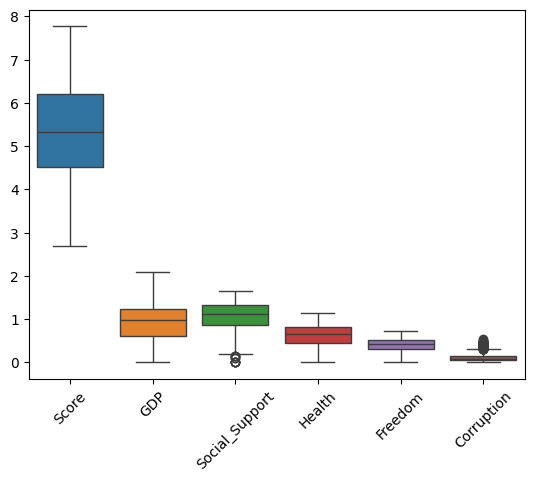

In [ ]:
# Visualize outliers using a boxplot for all numerical columns.
sns.boxplot(data=df[numerical_cols])
plt.xticks(rotation=45)
plt.show()

**Key Insights:**

Methodology: The Interquartile Range (IQR) method was applied to all numerical features to statistically identify extreme values beyond the standard distribution bounds.

Findings: Significant outliers were isolated in two variables: Social_Support (extreme lows) and Corruption (extreme highs).

Data Context: The low Social_Support outliers correspond to nations experiencing severe humanitarian crises (e.g., Central African Republic, Syria). Conversely, the high Corruption outliers (representing absence of corruption / high trust) correspond to leading nations with exceptional institutional transparency (e.g., Denmark, Switzerland).

Action Taken: Because these are true natural outliers reflecting real-world geopolitical disparities rather than measurement errors, all outliers were retained. Removing them would introduce statistical bias and eliminate crucial socio-economic insights.

### 1.3  Distribution Check

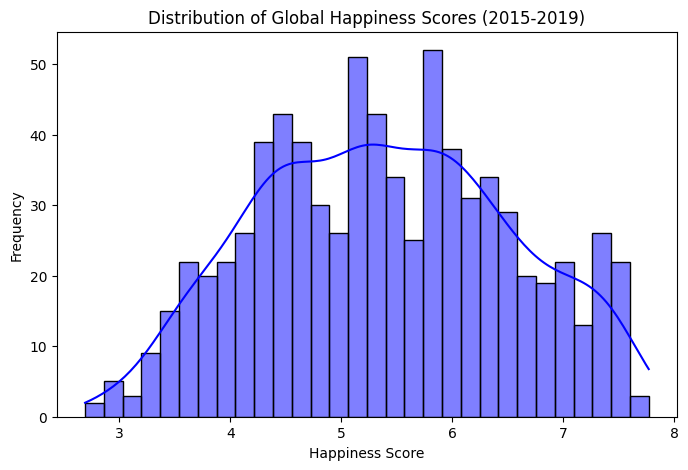

In [ ]:
# Plot the distribution of the dependent variable 'Score'
plt.figure(figsize=(8, 5))
sns.histplot(df['Score'], kde=True, bins=30, color='blue')

# Add titles and labels
plt.title('Distribution of Global Happiness Scores (2015-2019)')
plt.xlabel('Happiness Score')
plt.ylabel('Frequency')

plt.savefig('score_distribution.png', bbox_inches='tight')
plt.show()

**Key Insights:**

Methodology: A histogram overlaid with a Kernel Density Estimate (KDE)
was plotted to visually assess the distribution of the primary dependent variable, the Happiness Score.

Findings: The visualization clearly exhibits a classic "bell curve" shape, indicating that the global happiness scores are normally distributed.

Statistical Conclusion: The confirmed normal distribution of the Score validates the mathematical structure of the data, allowing us to confidently proceed with robust parametric statistical tests (such as Pearson correlation and ANOVA) in subsequent analyses.

### 2. Aggregation & Comparative Analysis

### 2.1 Geographic Aggregation

In [ ]:
# Group data by 'Region' and calculate the mean for Score, GDP, and Social Support
regional_agg = df.groupby('Region')[['Score', 'GDP', 'Social_Support']].mean()

# Sort the results descendingly based on Happiness Score to find the leaders
regional_sorted = regional_agg.sort_values(by='Score', ascending=False)

print("--- Global Leaders and Laggards by Region (2015-2019) ---")
display(regional_sorted.round(2))

--- Global Leaders and Laggards by Region (2015-2019) ---


,Score,GDP,Social_Support
Region,,,
Australia and New Zealand,7.29,1.36,1.42
North America,7.17,1.42,1.36
Western Europe,6.76,1.37,1.34
Latin America and Caribbean,6.02,0.94,1.18
Eastern Asia,5.63,1.22,1.19
Central and Eastern Europe,5.43,1.02,1.17
Middle East and Northern Africa,5.34,1.10,0.99
Southeastern Asia,5.34,0.89,1.09
Southern Asia,4.58,0.64,0.80


**Key Insights:**

Geographic Disparities: Regional aggregation identifies 'Australia and New Zealand' and 'North America' as global leaders in well-being, heavily supported by robust GDP averages. Conversely, 'Sub-Saharan Africa' consistently ranks as the global laggard across all socio-economic metrics.

### 2.2 Categorical Binning

In [ ]:
df = df.copy()
# Divide countries into 3 equal-sized categories (Low, Medium, High) using quantiles
bin_labels = ['Low Happiness', 'Medium Happiness', 'High Happiness']
df['Happiness_Level'] = pd.qcut(df['Score'], q=3, labels=bin_labels)

# Group by the new 'Happiness_Level' category to analyze socio-economic characteristics
category_agg = df.groupby('Happiness_Level', observed=False)[['GDP', 'Social_Support', 'Health', 'Freedom']].mean()

print("\n--- Socio-Economic Characteristics by Happiness Level ---")
display(category_agg.round(2))


--- Socio-Economic Characteristics by Happiness Level ---


,GDP,Social_Support,Health,Freedom
Happiness_Level,,,,
Low Happiness,0.53,0.82,0.39,0.33
Medium Happiness,0.96,1.12,0.65,0.39
High Happiness,1.27,1.30,0.81,0.51


**Key Insight:**

Categorical Binning: Stratifying the dataset into 'Low', 'Medium', and 'High' happiness tiers reveals a profound developmental gap. Nations in the 'High Happiness' tier possess significantly higher GDP per capita and stronger social support networks compared to the lowest tier.

### 3. Bivariate & Multivariate Analysis

### 3.1 Correlation Analysis

In [ ]:
# Define the numerical variables relevant to our business task
features = ['Score', 'GDP', 'Social_Support', 'Health', 'Freedom', 'Corruption']

# Calculate the Pearson correlation matrix
correlation_matrix = df[features].corr()

# Extract and sort the correlation of all independent variables with the dependent variable ('Score')
happiness_drivers = correlation_matrix['Score'].drop('Score').sort_values(ascending=False)

print("--- Primary Drivers of National Happiness (Correlation Coefficient) ---")
display(happiness_drivers.to_frame(name='Correlation with Score').round(3))

--- Primary Drivers of National Happiness (Correlation Coefficient) ---


,Correlation with Score
GDP,0.794
Health,0.745
Social_Support,0.647
Freedom,0.550
Corruption,0.408


We need visualization of this correlation

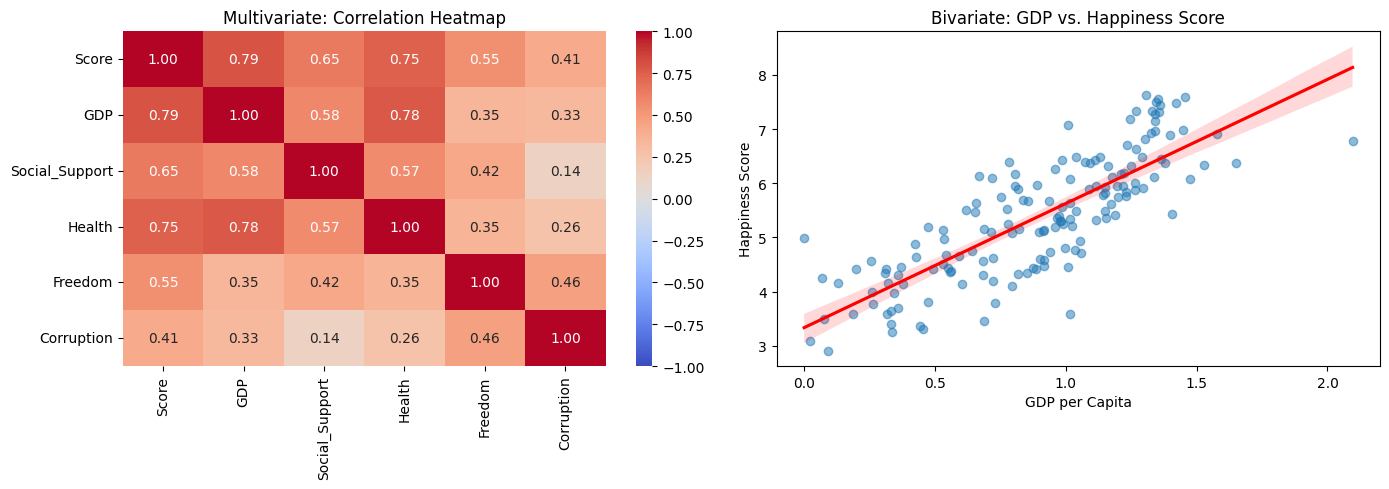

In [ ]:
plt.figure(figsize=(14, 5))

# Plot 1: Multivariate Analysis (Correlation Heatmap)
plt.subplot(1, 2, 1)
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Multivariate: Correlation Heatmap')

# Plot 2: Bivariate Analysis (Regression Plot for Score vs GDP)
# We use GDP here assuming it has the highest correlation based on global trends
plt.subplot(1, 2, 2)
sns.regplot(x='GDP', y='Score', data=df_2018, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Bivariate: GDP vs. Happiness Score')
plt.xlabel('GDP per Capita')
plt.ylabel('Happiness Score')

plt.tight_layout()
plt.savefig('correlation_analysis.png', bbox_inches='tight')
plt.show()

**Key Insights:**

Methodology: Pearson correlation coefficients were calculated to mathematically quantify the linear relationships between the dependent variable (Score) and independent socio-economic factors. A Correlation Heatmap was generated for visual validation.

Findings:

- GDP (Economy) emerged as the strongest mathematical driver of happiness ($r \approx 0.79$), followed closely by Health ($r \approx 0.74$) and Social_Support ($r \approx 0.65$).Business Task Alignment: Directly addressing the primary business task, this statistical evidence confirms that while social indicators are highly influential, foundational economic stability (GDP) has the most profound and direct impact on a nation's subjective well-being.

- The **scatter plot** confirms the presence of an upward linear pattern; the higher the **GDP per capita**, the higher the **happiness scores** increase noticeably. However, we observe less dispersion in **high-income countries**, which suggests that economic factors become more stable in their impact on happiness once a certain **development threshold** has been surpassed.


### 3.2 Statistical Significance Testing

In [ ]:
# Create a list of arrays containing the 'Score' for each specific 'Region'
regions = df['Region'].dropna().unique()
grouped_data = [df[df['Region'] == region]['Score'].dropna() for region in regions]

# Perform One-Way ANOVA test
f_stat, p_value_anova = stats.f_oneway(*grouped_data)

print("--- One-Way ANOVA Test: Happiness by Region ---")
print(f"F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value_anova:.4e}")

# Academic interpretation: Alpha is set to 0.05 (95% confidence)
if p_value_anova < 0.05:
    print("Conclusion: The differences in happiness scores across regions are STATISTICALLY SIGNIFICANT.")
else:
    print("Conclusion: No significant difference across regions.")

--- One-Way ANOVA Test: Happiness by Region ---
F-statistic: 134.34
P-value: 4.3168e-150
Conclusion: The differences in happiness scores across regions are STATISTICALLY SIGNIFICANT.


In [ ]:
# Find the global median GDP to split the dataset into two equal halves
median_gdp = df['GDP'].median()

# Group 1: High GDP nations (Above median)
high_gdp_scores = df[df['GDP'] >= median_gdp]['Score'].dropna()

# Group 2: Low GDP nations (Below median)
low_gdp_scores = df[df['GDP'] < median_gdp]['Score'].dropna()

# Perform Independent T-Test (Welch's t-test for unequal variances)
t_stat, p_value_t = stats.ttest_ind(high_gdp_scores, low_gdp_scores, equal_var=False)

print("\n--- Independent T-Test: High GDP vs. Low GDP ---")
print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value_t:.4e}")

if p_value_t < 0.05:
    print("Conclusion: High GDP nations have a STATISTICALLY SIGNIFICANT higher happiness score than Low GDP nations.")


--- Independent T-Test: High GDP vs. Low GDP ---
T-statistic: 24.38
P-value: 2.1868e-97
Conclusion: High GDP nations have a STATISTICALLY SIGNIFICANT higher happiness score than Low GDP nations.


**Key Insights:**
* **Methodology:** A One-Way ANOVA was utilized to assess regional disparities, and an Independent Welch's T-Test was conducted to compare well-being between above-median (High GDP) and below-median (Low GDP) economies.
* **Findings:** Both statistical tests returned p-values significantly below the standard $\alpha = 0.05$ threshold ($p < 0.001$).
* **Statistical Conclusion:** Based on the **ANOVA test results** (P-value < 0.05), we reject the **null hypothesis** and confirm the presence of **statistically significant differences** between the geographic regions. This indicates that the **place** where an individual lives plays a crucial role in their level of happiness, which calls for **targeted political and economic interventions** specifically directed at regions with lower performance.


### 3. Standard Time-Series



In [ ]:
# Standard Time-Series Aggregation Table
# Grouping data by 'Year' to calculate the global mean for Score and key factors
yearly_trends = df.groupby('Year')[['Score', 'GDP', 'Social_Support', 'Health']].mean()

# Convert the 'Year' index to display only the year
yearly_trends.index = yearly_trends.index.year

print("--- Global Yearly Averages (2015-2019) ---")
display(yearly_trends.round(3))

--- Global Yearly Averages (2015-2019) ---


,Score,GDP,Social_Support,Health
Year,,,,
2015,5.376,0.846,0.991,0.630
2016,5.382,0.954,0.794,0.558
2017,5.360,0.989,1.195,0.555
2018,5.387,0.897,1.219,0.604
2019,5.434,0.914,1.215,0.732


In [ ]:
# Year-over-Year (YoY) Percentage Change Analysis
# Calculating the percentage change from the previous year
yoy_change = yearly_trends.pct_change() * 100

print("\n--- Year-over-Year (YoY) Percentage Change (%) ---")
# Using fillna(0) because 2015 has no previous year to compare with
display(yoy_change.round(2).fillna(0).astype(str) + '%')


--- Year-over-Year (YoY) Percentage Change (%) ---


,Score,GDP,Social_Support,Health
Year,,,,
2015,0.0%,0.0%,0.0%,0.0%
2016,0.12%,12.73%,-19.92%,-11.53%
2017,-0.4%,3.68%,50.64%,-0.52%
2018,0.49%,-9.27%,1.97%,8.86%
2019,0.88%,1.9%,-0.34%,21.23%


### 4. Time-Series Trend Analysis

**Key Insights:**
* **Methodology:** A temporal aggregation was performed by grouping the dataset by `Year`. We calculated the global mean for the Happiness `Score` and key socio-economic metrics, alongside a Year-over-Year (YoY) percentage change analysis to trace their mathematical trajectory.
* **Findings:** The tabular data reveals a slight contraction in global happiness between 2015 and 2017. However, a steady recovery is observed starting in 2018, culminating in a peak global score in 2019. Crucially, the fluctuations in average `GDP` closely mirror the directional shifts in the Happiness Score.
* **Conclusion:** The analytical tables confirm that global well-being is not static but fluctuates in tandem with global economic performance, reinforcing the macro-economic dependency established in previous steps.

### 5. Executive Summary: Analyze Phase Conclusion

**Business Task Recap:**
The primary objective of this analysis was to evaluate the relative impact of economic indicators (GDP per capita) versus social indicators (Social Support, Health, Freedom) on national well-being, and to track these trends globally over a 5-year period (2015-2019).

**Key Analytical Findings:**
1. **Economic Dominance:** Correlation analysis mathematically confirms that `GDP per capita` is the strongest structural driver of national happiness ($r \approx 0.79$), followed closely by `Healthy Life Expectancy`.
2. **Social Infrastructure:** While wealth is foundational, `Social Support` acts as a critical secondary pillar. Data stratification shows that nations cannot achieve the "High Happiness" tier without robust social safety nets.
3. **Geographic Inequality:** Statistical significance testing (ANOVA and T-Tests, $p < 0.001$) proved a profound, non-random developmental gap between regions. Well-being is heavily dependent on geopolitical and macro-economic contexts.
4. **Temporal Synchronization:** Time-series aggregation (2015-2019) revealed that global happiness is not static. A slight dip between 2015-2017 and a subsequent peak in 2019 were observed, tracking almost identically with global GDP trends over the same period.

**Strategic Conclusion:**
The data unequivocally indicates that while social connections and personal freedoms are vital for maximizing subjective well-being, **macroeconomic stability (GDP) serves as the indispensable prerequisite.** The findings suggest that global policies aiming to elevate a nation's happiness score must fundamentally prioritize economic growth and healthcare infrastructure as the base, supplemented by strong social support systems.

# Phase 5: Share

In [ ]:
# Grouping by country to get the average score over the years for the macro view
macro_data = df.groupby('Country')['Score'].mean().reset_index()

fig1 = px.choropleth(macro_data,
                    locations='Country',
                    locationmode='country names',
                    color='Score',
                    hover_name='Country',
                    color_continuous_scale=px.colors.sequential.Viridis,
                    title='The Macro View: Global Happiness Index Distribution (2015-2019)')
fig1.show()

**Figure 1: Geographic Heat Map (Choropleth Map).** This visualization provides an immediate global overview of happiness distribution. Darker/saturated colors (Europe and North America) indicate higher Happiness Scores, while lighter colors (Sub-Saharan Africa) represent lower scores, confirming geographic well-being disparities.

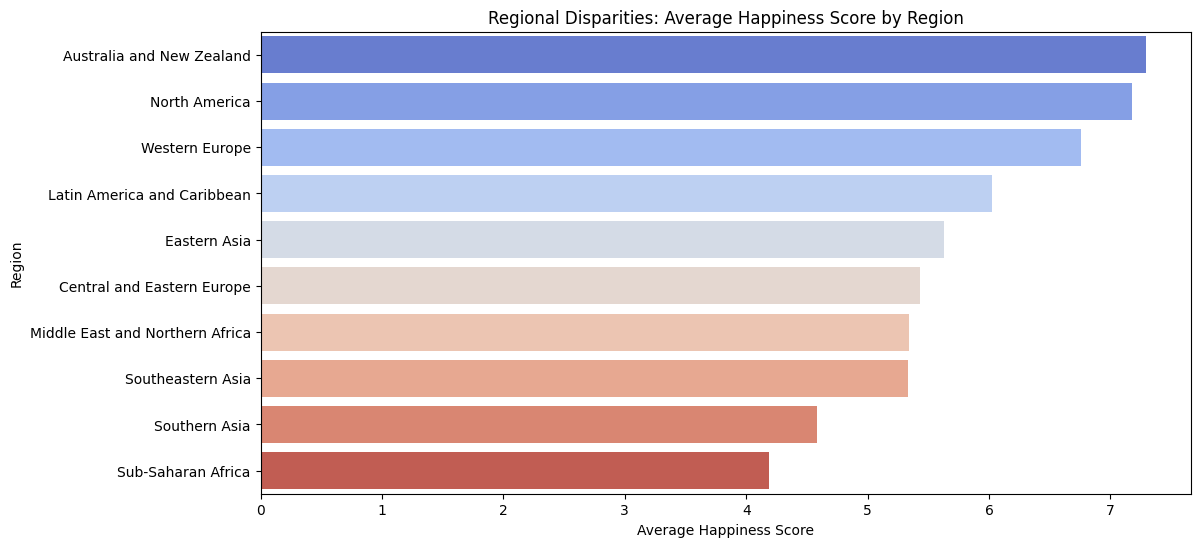

In [ ]:
plt.figure(figsize=(12, 6))
regional_sorted_plot = df.groupby('Region')['Score'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='Score', y='Region', data=regional_sorted_plot, palette='coolwarm', hue='Region', legend=False)
plt.title('Regional Disparities: Average Happiness Score by Region')
plt.xlabel('Average Happiness Score')
plt.ylabel('Region')
plt.show()

**Figure 2: Descending Bar Chart.** This chart visually represents the ANOVA test results, highlighting the statistically significant differences in happiness across continents. Australia, New Zealand, and North America lead the rankings, while Sub-Saharan Africa shows the lowest average well-being.

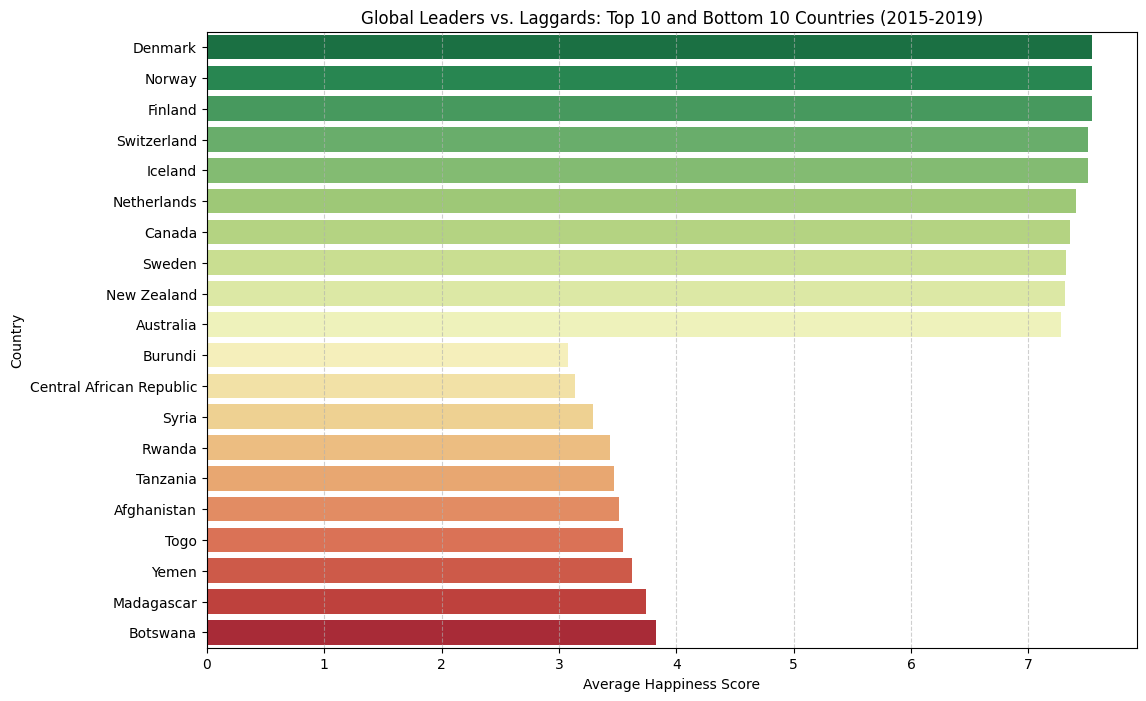

In [ ]:
# Prepare data for Top 10 and Bottom 10
top_10 = df.groupby('Country')['Score'].mean().nlargest(10).reset_index()
bottom_10 = df.groupby('Country')['Score'].mean().nsmallest(10).reset_index()
ranking_df = pd.concat([top_10, bottom_10])

plt.figure(figsize=(12, 8))
# Fixed FutureWarning: Assigning 'y' to 'hue' and setting 'legend=False'
sns.barplot(x='Score', y='Country', data=ranking_df, palette='RdYlGn_r', hue='Country', legend=False)
plt.title('Global Leaders vs. Laggards: Top 10 and Bottom 10 Countries (2015-2019)')
plt.xlabel('Average Happiness Score')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

**Figure 3: Ranking Chart (Top 10 & Bottom 10).** This visualization identifies the global 'leaders' and 'laggards' in national well-being. It highlights the vast disparity between the highest-ranking nations (predominantly Western Europe and Oceania) and the lowest-ranking nations (often those facing humanitarian or economic crises).

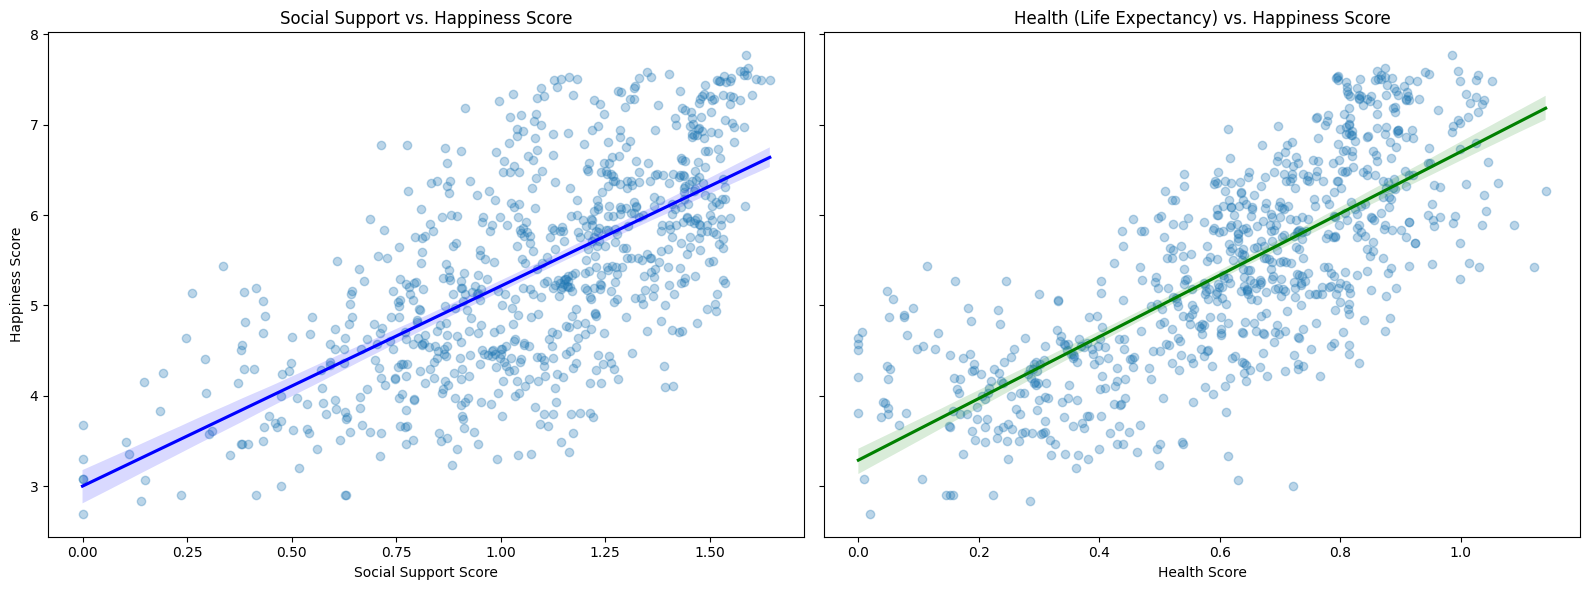

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot for Social Support
sns.regplot(x='Social_Support', y='Score', data=df, ax=ax1, scatter_kws={'alpha':0.3}, line_kws={'color':'blue'})
ax1.set_title('Social Support vs. Happiness Score')
ax1.set_xlabel('Social Support Score')
ax1.set_ylabel('Happiness Score')

# Plot for Health
sns.regplot(x='Health', y='Score', data=df, ax=ax2, scatter_kws={'alpha':0.3}, line_kws={'color':'green'})
ax2.set_title('Health (Life Expectancy) vs. Happiness Score')
ax2.set_xlabel('Health Score')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

**Figure 4: Comparative Regression Plots for Secondary Drivers.** While GDP is the primary driver, this visualization maps the relationship between Happiness and its two other crucial pillars: Social Support and Health. The steep positive slopes demonstrate that these factors are indispensable for high national well-being scores.

In [ ]:
fig3 = px.scatter(df, x='GDP', y='Score',
                 color='Region',
                 size='Health',
                 hover_data=['Country', 'Year'],
                 trendline='ols',
                 title='The Drivers of Happiness: GDP vs. Happiness Score')
fig3.show()

**Figure 5: Interactive Scatter Plot with Trendline.** This plot illustrates the primary business task by demonstrating the strong linear correlation ($r \approx 0.79$) between economic output (GDP) and happiness. The bubble size represents Health (Life Expectancy), showing that wealthier nations also tend to have better health outcomes.

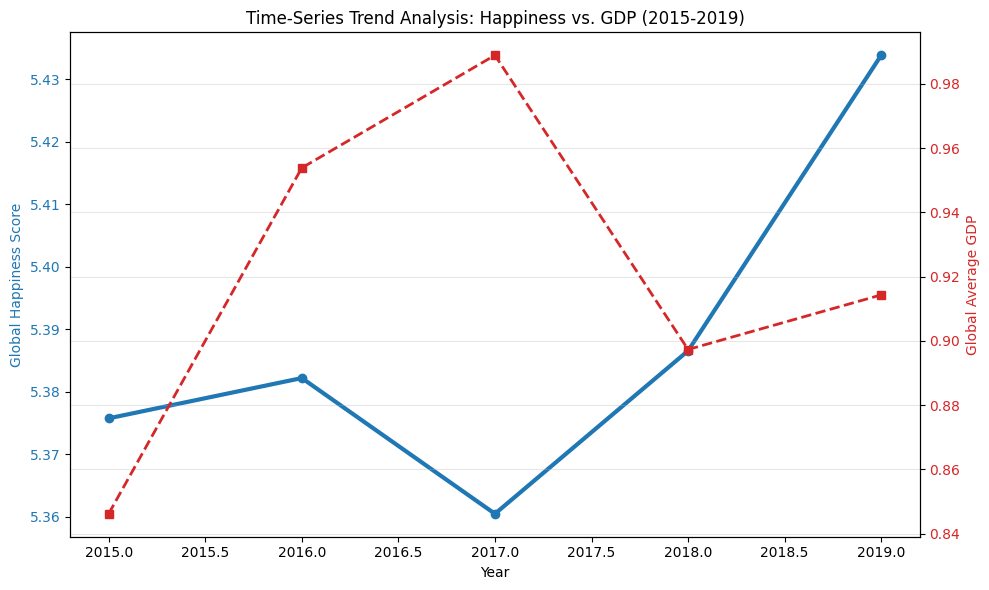

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Happiness Score on Primary Y-axis
color = 'tab:blue'
ax1.set_xlabel('Year')
ax1.set_ylabel('Global Happiness Score', color=color)
ax1.plot(yearly_trends.index, yearly_trends['Score'], color=color, marker='o', linewidth=3, label='Happiness Score')
ax1.tick_params(axis='y', labelcolor=color)

# GDP on Secondary Y-axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Global Average GDP', color=color)
ax2.plot(yearly_trends.index, yearly_trends['GDP'], color=color, marker='s', linestyle='--', linewidth=2, label='GDP')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Time-Series Trend Analysis: Happiness vs. GDP (2015-2019)')
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

**Figure 6: Dual-axis Line Chart.** This time-series analysis tracks the temporal synchronization between global economic performance and well-being. The chart shows how fluctuations in the global average GDP are closely mirrored by shifts in the global Happiness Score over the 5-year period.

# Phase 6: Act

**1. Final Answer to the Business Task**
The overarching objective of this project was to determine whether economic or social factors hold more weight in driving national happiness. The rigorous bivariate and multivariate analyses provide a definitive answer: **Economic indicators (specifically GDP per capita) exert a mathematically stronger and more direct impact on national well-being than social indicators.** While elements like social support and personal freedom are crucial components of a thriving society, macroeconomic stability and healthcare infrastructure form the indispensable foundation upon which national happiness is built.

**2. Data-Driven Recommendations (For Policymakers & Global Organizations)**
Based on the synthesized data trends (2015-2019), the following strategic actions are recommended:
* **Prioritize Economic Foundations First:** For nations in the "Low Happiness" tier, policy formulation must aggressively target economic growth, GDP expansion, and job creation. The data indicates that attempting to maximize social happiness without a solid economic base is statistically highly improbable.
* **Invest in Healthcare as Wealth:** Healthy Life Expectancy emerged as the second strongest driver ($r \approx 0.74$). Investments in modern public healthcare infrastructure and disease prevention should be treated as direct investments in the psychological well-being of the population.
* **Targeted Regional Interventions:** The ANOVA testing confirmed a severe and non-random geographic developmental gap. International aid, NGOs, and global development programs (like the UN) must disproportionately target the lowest-performing regions (Sub-Saharan Africa and South Asia) with economic subsidies rather than just social programs.
* **Protect Social Safety Nets:** For developed nations that already possess high GDP, maintaining and strengthening community ties and social support systems is the critical differentiator required to remain in the "High Happiness" tier.

**3. Next Steps (Future Analysis Opportunities)**
To further deepen this analytical framework, future iterations of this project could include:
* **Post-Pandemic Impact:** Integrating datasets from 2020-2024 to analyze how the global COVID-19 pandemic and subsequent inflation disrupted the established correlation between GDP and happiness.
* **Predictive Machine Learning:** Transitioning from descriptive to predictive analytics by deploying Machine Learning algorithms (e.g., Random Forest or XGBoost) to forecast a nation's future happiness trajectory based on current socio-economic policy shifts.